# Seleccion de Variables con Lasso


En el presente notebook se generan y se evalúan los siguientes modelos.

* Regresión lineal Lasso
* Regresión lineal
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica

El preprocesamiento principal se realiza mediante una seleccion de variables utilizando el metodo de regresion Lasso. 

In [1]:
library(pracma)
library(glmnet)
library("stats")
library("partykit")
source("Utils.R")

Loading required package: Matrix

Attaching package: ‘Matrix’

The following objects are masked from ‘package:pracma’:

    expm, lu, tril, triu

Loading required package: foreach
Loaded glmnet 2.0-16

Loading required package: grid
Loading required package: libcoin
Loading required package: mvtnorm


### Division de los datos

In [2]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y


hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

# Seleccion de Variables con Lasso

### Modelo sin tuneo de parametros y sin escalar 

In [3]:
model <- glmnet(as.matrix(TRAIN_X), TRAIN_Y, alpha=1)

In [4]:
Y_pred = predict(model, as.matrix(TRAIN_X))
error_min <- sum((TRAIN_Y - Y_pred[, 1])^2) / nrow(TRAIN_X)
best_model <- 1
for (i in 2:ncol(Y_pred)) {
    curr_error <- sum((TRAIN_Y - Y_pred[, i])^2) / nrow(TRAIN_X)
    if (curr_error < error_min) {
        error_min <- curr_error 
        best_model <- i
    }
}
print(paste("El error cuadratico medio de train es: ", error_min, " usando el modelo numero: ", best_model))

[1] "El error cuadratico medio de train es:  0.694377895643682  usando el modelo numero:  100"


In [5]:
best_lambda = model$lambda[100]
print(paste("El lambda utilizado es: ", best_lambda))

[1] "El lambda utilizado es:  0.0372287988245699"


In [6]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = X[-i,]
    Y_train = TRAIN_Y[-i]

    X_test_scaled = X[i,]
    Y_test = TRAIN_Y[i]

    model <- glmnet(as.matrix(X_train_scaled), Y_train, alpha=1, lambda = best_lambda)
    Y_pred = predict(model, as.matrix(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.26012561111025"


### Busqueda del mejor lambda

In [7]:
setSeed()
n = nrow(TRAIN_X)
k = 5
resultados <- data.frame(
  Lambda  =double(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- TRAIN_X

lambdas <- logspace(-10, 3, 50)
alpha = 1
for (lambda in lambdas) {
    err = 0
    for (i in indices) {
        X_train_scaled = scale(X[-i,])
        Y_train = TRAIN_Y[-i]

        X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                      scale=attr(X_train_scaled, "scaled:scale"))

        Y_test = TRAIN_Y[i]

        model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
        Y_pred = predict(model, X_test_scaled)
        err = err + sum((Y_test - Y_pred)^2)
    }
    resultados = rbind(resultados, list(lambda, err/n))
}

colnames(resultados)  <- c("lambda", "Error")

Los mejores parámetros obtenidos fueron entonces:

In [8]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,lambda,Error
31,0.009102982,0.9994413


### Calculo del error por LOOCV

In [9]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = scale(X[-i,])
    Y_train = TRAIN_Y[-i]

    X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                  scale=attr(X_train_scaled, "scaled:scale"))

    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=1)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.844437940474463"


Vemos que el error de LOOCV dio menor

In [10]:
X_scaled <- scale(TRAIN_X)
X_holdout_scaled <- scale(HOLDOUT_X, center=attr(X_scaled, "scaled:center"),
                          scale=attr(X_scaled, "scaled:scale"))
model <- glmnet(X_scaled, TRAIN_Y, alpha=1, lambda=mejores_parametros$lambda)

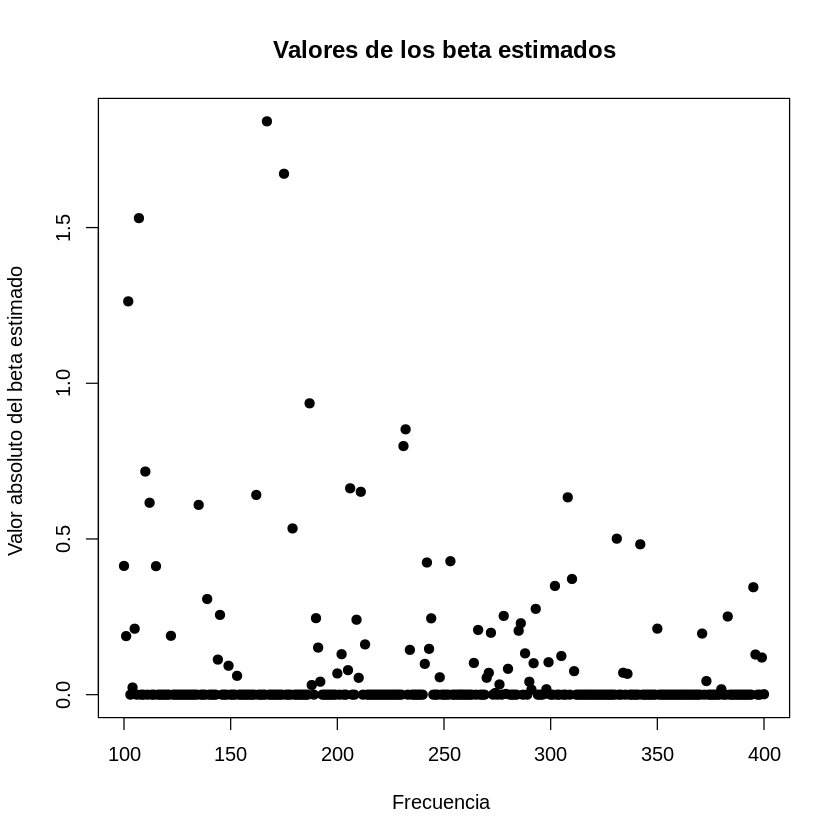

In [11]:
plot(x = seq(100, 400,1), y = abs(model$beta[,1]), main="Valores de los beta estimados",
     xlab="Frecuencia ", ylab="Valor absoluto del beta estimado ", pch=19)

In [12]:
variables_to_filter = model$beta[,1] != 0
print(paste("El mejor modelo de Lasso encontrado elimino ", sum(model$beta[,1] == 0), " variables"))

[1] "El mejor modelo de Lasso encontrado elimino  219  variables"


In [13]:
SELECTED_TRAIN_X <- TRAIN_X[, variables_to_filter]
SELECTED_TRAIN_DF <- SELECTED_TRAIN_X
SELECTED_TRAIN_DF$Y <- TRAIN_Y

SELECTED_HOLDOUT_X <- HOLDOUT_X[, variables_to_filter]
SELECTED_HOLDOUT_DF <- SELECTED_HOLDOUT_X
SELECTED_HOLDOUT_DF$Y <- HOLDOUT_Y

# Modelo 1: Regresion Lineal

In [52]:
# No escalamos los datos porque no hay regularizacion.

model <- lm(Y~., data = SELECTED_TRAIN_DF)

Y_pred = predict(model, SELECTED_TRAIN_X)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(SELECTED_TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.101794159667565"


In [53]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    df_train = X[-i,]
    df_train$Y = TRAIN_Y[-i]
    
    X_test = X[i,]
    Y_test = TRAIN_Y[i]

    model <- lm(Y~.,  data = df_train)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.4556017240322"


# Modelo 2: Regresion Lineal Regularizada

### Sólo iterando lambda y sin escalar

In [54]:
model <- glmnet(as.matrix(SELECTED_TRAIN_X), TRAIN_Y)

In [55]:
Y_pred = predict(model, as.matrix(SELECTED_TRAIN_X))
error_min <- sum((TRAIN_Y - Y_pred[, 1])^2) / nrow(SELECTED_TRAIN_X)
best_model <- 1
for (i in 2:ncol(Y_pred)) {
    curr_error <- sum((TRAIN_Y - Y_pred[, i])^2) / nrow(SELECTED_TRAIN_X)
    if (curr_error < error_min) {
        error_min <- curr_error 
        best_model <- i
    }
}
print(paste("El error cuadratico medio de train es: ", error_min, " usando el modelo numero: ", best_model))

[1] "El error cuadratico medio de train es:  0.104858837471819  usando el modelo numero:  96"


In [57]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = X[-i,]
    Y_train = TRAIN_Y[-i]

    X_test_scaled = X[i,]
    Y_test = TRAIN_Y[i]

    model <- glmnet(as.matrix(X_train_scaled), Y_train, lambda=0.0372, alpha=1)
    Y_pred = predict(model, as.matrix(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.15218857472908"


### Busqueda de los parametros de la prediccion

In [58]:
setSeed()
n = nrow(SELECTED_TRAIN_X)
k = 5
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

alphas <- seq(0, 1, 0.05)
lambdas <- logspace(-10, 3, 50)

for (alpha in alphas) {
    for (lambda in lambdas) {
        err = 0
        for (i in indices) {
            X_train_scaled = scale(X[-i,])
            Y_train = TRAIN_Y[-i]

            X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                          scale=attr(X_train_scaled, "scaled:scale"))

            Y_test = TRAIN_Y[i]

            model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
            Y_pred = predict(model, X_test_scaled)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(alpha, lambda, err/n))
    }
    message(progreso(alpha, alphas))
}

colnames(resultados)  <- c("alpha", "lambda", "Error")

El progreso es del 4.8 %
El progreso es del 9.5 %
El progreso es del 14.3 %
El progreso es del 19 %
El progreso es del 23.8 %
El progreso es del 28.6 %
El progreso es del 33.3 %
El progreso es del 38.1 %
El progreso es del 42.9 %
El progreso es del 47.6 %
El progreso es del 52.4 %
El progreso es del 57.1 %
El progreso es del 61.9 %
El progreso es del 66.7 %
El progreso es del 71.4 %
El progreso es del 76.2 %
El progreso es del 81 %
El progreso es del 85.7 %
El progreso es del 90.5 %
El progreso es del 95.2 %
El progreso es del 100 %


Los mejores parámetros obtenidos fueron entonces:

In [59]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,alpha,lambda,Error
32,0,0.01676833,0.3543098


### Calculo del error por LOOCV

In [60]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = scale(X[-i,])
    Y_train = TRAIN_Y[-i]

    X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                  scale=attr(X_train_scaled, "scaled:scale"))

    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.35506818958812"


### Grafico de los beta estimados

In [61]:
X_scaled <- scale(SELECTED_TRAIN_X)
modelo2 <- glmnet(X_scaled, TRAIN_Y, alpha=mejores_parametros$alpha, lambda=mejores_parametros$lambda)

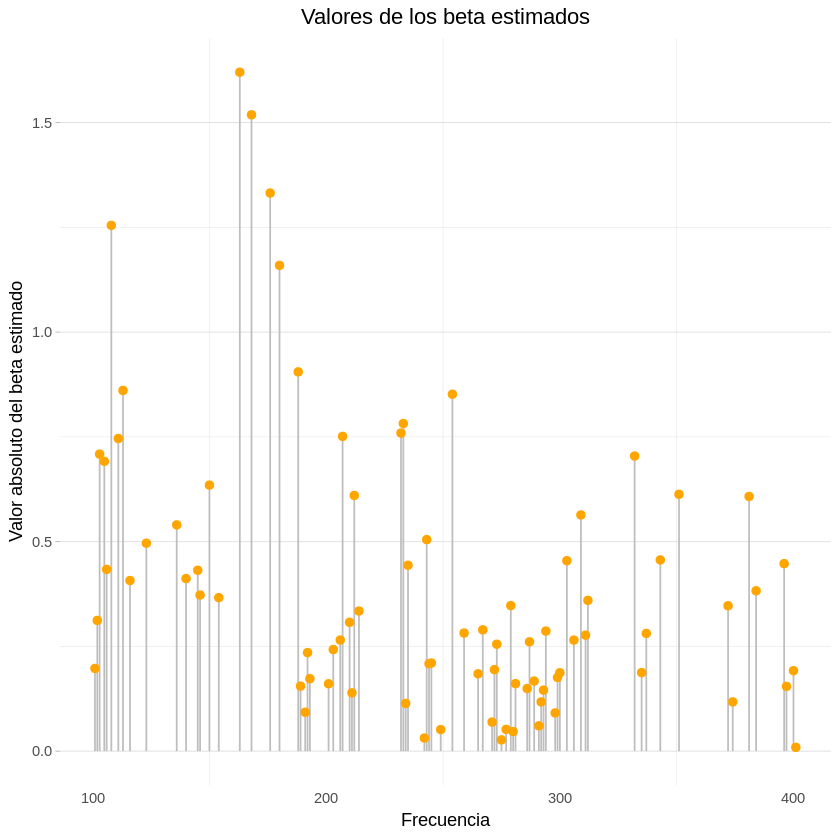

In [91]:
x_plot = as.integer(sub('.', '', colnames(SELECTED_TRAIN_X))) + 100

data_plot <- data.frame(
  x=x_plot,
  y=abs(modelo2$beta[,1])
)


# Plot
ggplot(data_plot, aes(x=x, y=y)) +
  ggtitle("Valores de los beta estimados") +
  geom_segment( aes(x=x, xend=x, y=0, yend=y), color="grey") +
  geom_point( color="orange", size=2) +
  theme_light() +
  theme(
    panel.grid.major.x = element_blank(),
    panel.border = element_blank(),
    axis.ticks.x = element_blank(), 
    plot.title = element_text(hjust = 0.5)
  ) +
  xlab("Frecuencia") +
  ylab("Valor absoluto del beta estimado") 
  

# Modelo 3: árbol de regresión

### Sin tuneo de parametros

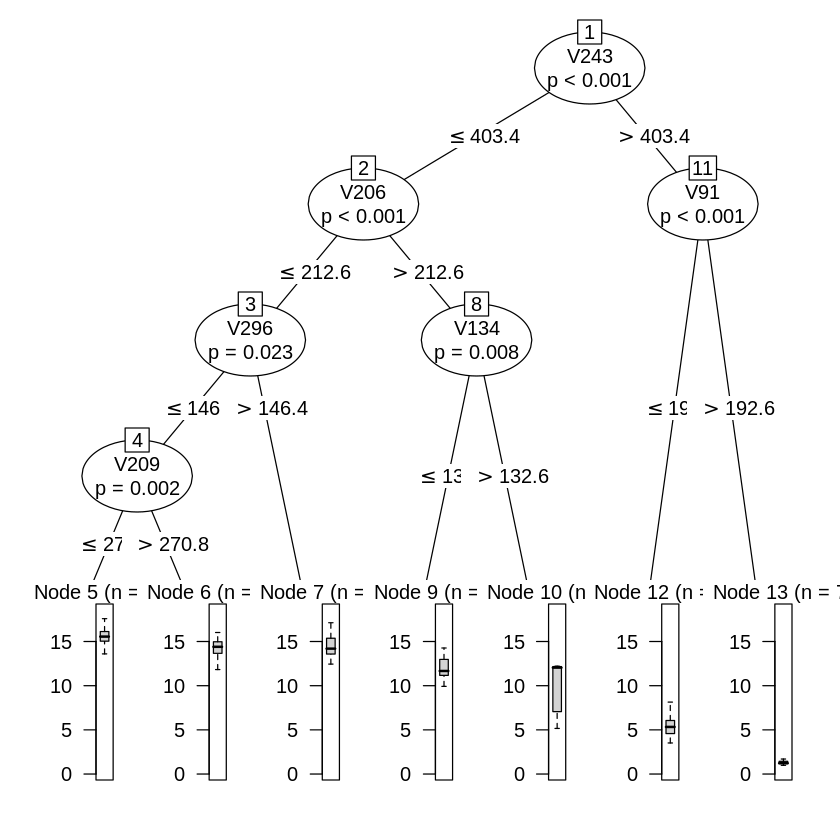

In [92]:
model <- ctree(Y ~ ., data = SELECTED_TRAIN_DF)
plot(model)

In [100]:
Y_pred = predict(model, SELECTED_TRAIN_X)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(SELECTED_TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    df_train = X[-i,]
    df_train$Y = TRAIN_Y[-i]
    
    X_test = X[i,]
    Y_test = TRAIN_Y[i]

    model <- ctree(Y ~ ., data = df_train)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio de train es:  1.11458678286712"
[1] "El error cuadratico medio con LOOCV de train es:  2.57561865526944"


### Busqueda de los parametros de la prediccion

In [94]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  Alpha    =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X

minsplits <- c(2, 5, 10, 20, 30, 50)

for (minsplit in minsplits) {
    for (maxdepth in c(1, 2, 3, 4, 5, Inf)) {
        for (alpha in c(0.005, 0.01, 0.025, 0.05, 0.75, 0.1, 0.15)) {
            parametros = ctree_control(minsplit=minsplit, maxdepth=maxdepth, alpha=alpha)
            err = 0
            for(i in indices) {
                DF_train = X[-i,]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,]
                DF_test$Y = TRAIN_Y[i]

                model <- ctree(Y ~ ., data = DF_train, control=parametros)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, alpha, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "Alpha", "Error")

El progreso es del 16.7 %
El progreso es del 33.3 %
El progreso es del 50 %
El progreso es del 66.7 %
El progreso es del 83.3 %
El progreso es del 100 %


In [95]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,Minsplit,Maxdepth,Alpha,Error
26,2,4,0.75,2.388218


### Calculo del error

In [96]:
parametros <- ctree_control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, alpha=mejores_parametros$Alpha)

modelo3 <- ctree(Y ~ ., data = SELECTED_TRAIN_DF, control=parametros)

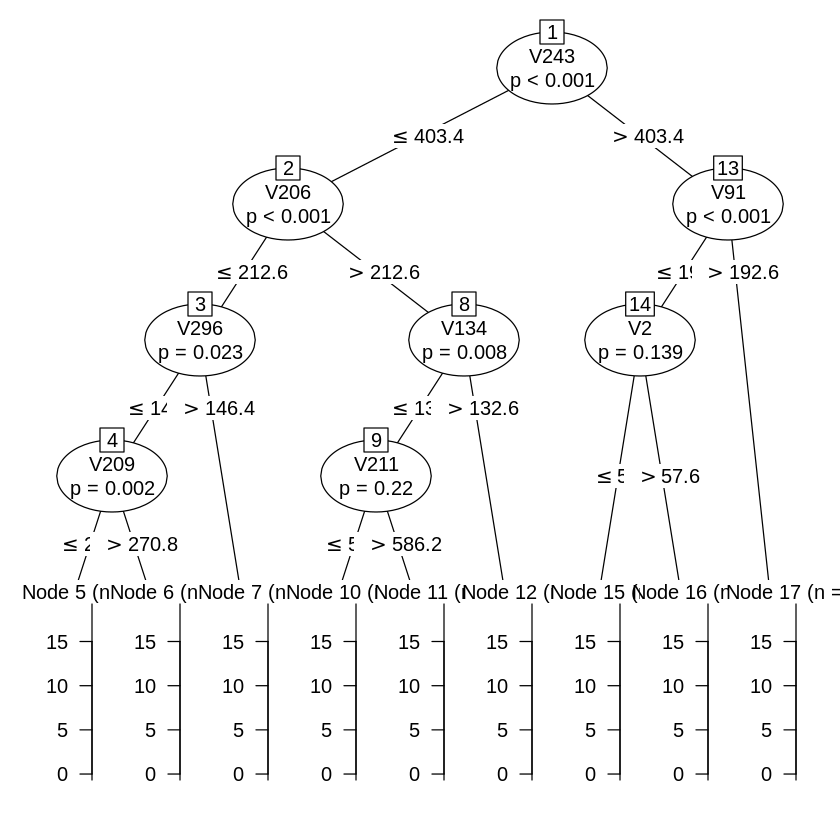

In [97]:
plot(modelo3)

In [98]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    train_df <- X[-i,]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- ctree(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  2.33128476158804"


# Modelo 3: KNN para regresión

In [101]:
library(reticulate)

In [102]:
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

In [111]:
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

### Sin tuneo de parametros

In [112]:
model <- knnr()$fit(SELECTED_TRAIN_X, TRAIN_Y)

In [113]:
Y_pred = as.double(model$predict(SELECTED_TRAIN_X))
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(SELECTED_TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.72084916375"


### Busqueda de los parametros de la prediccion

In [114]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X

for(K in 1:10){
    for(w in c(1, 2)){
        wei = ifelse(w==1, "uniform", "distance")
        for(p in c(1, 2)){
            err = 0
            for(i in indices){
                X_train_scaled = scale(X[-i,])
                Y_train = TRAIN_Y[-i]

                X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                              scale=attr(X_train_scaled, "scaled:scale"))
                Y_test = TRAIN_Y[i]

                model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)

                Y_pred = as.double(model$predict(X_test_scaled))
                err = err + sum((Y_test - Y_pred)^2)
            }
            resultados = rbind(resultados, list(K, w, p, err/n))
        }
    }
    message(progreso(K, 1:10))
}
colnames(resultados)  <- c("K", "Weights", "Distance", "Error")

El progreso es del 10 %
El progreso es del 20 %
El progreso es del 30 %
El progreso es del 40 %
El progreso es del 50 %
El progreso es del 60 %
El progreso es del 70 %
El progreso es del 80 %
El progreso es del 90 %
El progreso es del 100 %


In [115]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,K,Weights,Distance,Error
11,3,2,1,0.8509536


### Calculo del error

In [116]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    X_train_scaled = scale(X[-i,])
    Y_train = TRAIN_Y[-i]

    X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                  scale=attr(X_train_scaled, "scaled:scale"))
    Y_test = TRAIN_Y[i]
    
    wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
    model <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, Y_train)
    Y_pred = as.double(model$predict(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.843063792190208"


# Modelo 4: regresión no paramétrica

$$\hat{m}_{h}(x) = \frac{\sum^{n}_{i=1} K(\frac{x-x_i}{h}) y_i}{\sum^{n}_{i=1}K(\frac{x-x_i}{h})} = \sum^{n}_{i=1} w_i(x) y_i$$

In [118]:
mNW <- function(x, X, Y, h, K = dnorm) {
    # Arguments
    # x: evaluation points
    # X: vector (size n) with the predictors
    # Y: vector (size n) with the response variable
    # h: bandwidth
    # K: kernel
    yi = c()
    for(xi in x){
        Ki = sapply(X, function(Xi) K((xi - Xi) / h))
        yi = c(yi, ifelse(sum(Ki)==0, mean(Y), sum(Ki*Y)/sum(Ki)))
    }
    return(yi)
}

In [127]:
corr_matrix <- cor(SELECTED_TRAIN_DF, method = "pearson")
corr_pesos <- abs(as.data.frame(corr_matrix)$Y)[1:ncol(corr_matrix) - 1]

In [128]:
setSeed()
n = nrow(SELECTED_TRAIN_X)
J = ncol(SELECTED_TRAIN_X)
k = 10

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

resultados <- data.frame(
    h       =double(),
    K       =integer()
)

hs = seq(0.01, 1, l=20)
Ks = list((function(x) (0.5 * (abs(x)<1))),
          (function(x) (dnorm(x))),
          (function(x) (0.75*(1-x^2)*(abs(x)<1))),
          (function(x) ((15/16)*((1-x^2)^2)*(abs(x)<1)))
       )

for(j in 1:J){
    busqueda <- data.frame(
        h       =double(),
        K       =integer(),
        Error   =double()
    )
    Xj = X[, j]
    for(h in hs){
        for(Knumber in 1:length(Ks)){
            K = Ks[[Knumber]]
            err = 0
            for(i in indices){
                Xj_train_scaled = scale(Xj[-i])
                Y_train = TRAIN_Y[-i]

                Xj_test_scaled = scale(Xj[i], center=attr(Xj_train_scaled, "scaled:center"),
                              scale=attr(Xj_train_scaled, "scaled:scale"))
                Y_test = TRAIN_Y[i]

                Y_pred = mNW(x = Xj_test_scaled, X = Xj_train_scaled, Y = Y_train, h = h, K=K)
                err = err + sum((Y_test - Y_pred)^2)
            }
            busqueda = rbind(busqueda, list(h, Knumber, err/n))
        }
    }
    colnames(busqueda)  <- c("h", "K", "Error")
    # Calculo de los mejores hp
    mejores_hp <- busqueda[which.min(busqueda$Error), ]
    resultados = rbind(resultados, list(mejores_hp$h, mejores_hp$K))
    message(progreso(j, 1:J))
}
colnames(resultados)  <- c("h", "K")

El progreso es del 1.2 %
El progreso es del 2.4 %
El progreso es del 3.7 %
El progreso es del 4.9 %
El progreso es del 6.1 %
El progreso es del 7.3 %
El progreso es del 8.5 %
El progreso es del 9.8 %
El progreso es del 11 %
El progreso es del 12.2 %
El progreso es del 13.4 %
El progreso es del 14.6 %
El progreso es del 15.9 %
El progreso es del 17.1 %
El progreso es del 18.3 %
El progreso es del 19.5 %
El progreso es del 20.7 %
El progreso es del 22 %
El progreso es del 23.2 %
El progreso es del 24.4 %
El progreso es del 25.6 %
El progreso es del 26.8 %
El progreso es del 28 %
El progreso es del 29.3 %
El progreso es del 30.5 %
El progreso es del 31.7 %
El progreso es del 32.9 %
El progreso es del 34.1 %
El progreso es del 35.4 %
El progreso es del 36.6 %
El progreso es del 37.8 %
El progreso es del 39 %
El progreso es del 40.2 %
El progreso es del 41.5 %
El progreso es del 42.7 %
El progreso es del 43.9 %
El progreso es del 45.1 %
El progreso es del 46.3 %
El progreso es del 47.6 %
El

In [136]:
pesos <- corr_pesos^40

Y_pred = 0
for(j in 1:J){
    Xj = scale(SELECTED_TRAIN_X[, j])
    mp_h = resultados$h[j]
    mp_K = resultados$K[j]
    Y_pred = Y_pred + pesos[j] * mNW(Xj, Xj, TRAIN_Y, mp_h, Ks[[mp_K]])
}
Y_pred = Y_pred/sum(pesos)

In [137]:
mean((TRAIN_Y-Y_pred)^2)

[1] 2.190924